# Aula 07: tendências centrais com dados do Billboard

Este notebook acompanha a aula de **tendências centrais**. Ele foi escrito para ser usado como material de estudo: leia os textos, execute as células, altere alguns parâmetros e observe como as conclusões mudam.

Usaremos o dataset **Billboard Hits Songs Dataset**, disponível no Kaggle em `dem0nking/billboard-hits-songs-dataset`. Cada linha representa uma música e traz título, artista, gênero, data de lançamento, duração, álbum e popularidade.

## Objetivos do notebook

Ao final, você deve conseguir:

- fazer uma inspeção descritiva inicial de uma base;
- visualizar uma variável numérica antes de resumir;
- calcular e interpretar média, mediana, quartis, quantis, intervalo, variância e desvio padrão;
- entender por que outliers e assimetria afetam a média;
- conectar histogramas, CDF empírica, boxplots e resumos numéricos.

## Como estudar este capítulo

Medidas de centro só fazem sentido quando lidas junto com a forma e a dispersão da distribuição. Por isso, o capítulo começa pelos gráficos e depois constrói média, mediana, quantis, variância e desvio padrão. O objetivo não é escolher automaticamente um único número, mas compreender que aspecto dos dados cada resumo preserva.

A base Billboard funciona como fio condutor. Primeiro descrevemos duração e popularidade; depois alteramos artificialmente os dados para observar a sensibilidade dos resumos. Esses experimentos não corrigem a base: eles isolam mecanismos, como o efeito de um valor extremo sobre a média e a variância.

Antes de executar uma célula, tente prever o que acontecerá. Depois compare média e mediana, observe a posição dos quantis no gráfico e traduza variância e desvio padrão para a unidade do problema. Os códigos permitem reproduzir o raciocínio; as conclusões devem sempre retornar às músicas e à população representada.


## 1. Download do dataset

O código abaixo baixa a versão mais recente do dataset público no Kaggle. Em alguns ambientes, pode ser necessário instalar a biblioteca antes:

```bash
pip install kagglehub
```

A célula usa exatamente o identificador do dataset adotado nos slides.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dem0nking/billboard-hits-songs-dataset")

print("Path to dataset files:", path)


Path to dataset files: /Users/ramosh/.cache/kagglehub/datasets/dem0nking/billboard-hits-songs-dataset/versions/3


## 2. Preparação do ambiente

Carregamos as bibliotecas e definimos um estilo visual simples. O foco aqui não é programação avançada: o código serve para tornar os conceitos estatísticos visíveis.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 2)


## 3. Leitura e preparação dos dados

O download retorna uma pasta. Vamos procurar o arquivo `.csv`, carregar a tabela e converter a coluna `Duration`, que vem como texto no formato `minutos:segundos`, para uma coluna numérica em minutos.


In [3]:
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta baixada do Kaggle.")

csv_path = csv_files[0]
print("Arquivo usado:", csv_path.name)

raw = pd.read_csv(csv_path)
raw.head()


Arquivo usado: Iconic_Songs_Dataset.csv


,Title,Artist,Genre,ReleaseDate,Duration,Album,Popularity
0,Blinding Lights,The Weeknd,Pop,2024-01-05,3:22,After Hours,95
1,Levitating,Dua Lipa,Pop,2024-01-14,3:23,Future Nostalgia,93
2,Peaches,Justin Bieber ft. Daniel Caesar & Giveon,Pop,2024-02-12,3:18,Justice,91
3,Save Your Tears,The Weeknd,Pop,2024-02-18,3:36,After Hours,92
4,Good 4 U,Olivia Rodrigo,Pop,2024-03-05,2:58,SOUR,94


In [4]:
def duration_to_minutes(duration):
    """Converte uma duração no formato M:SS para minutos em número decimal."""
    minutes, seconds = str(duration).split(":")
    return int(minutes) + int(seconds) / 60

songs = raw.copy()
songs["duration_min"] = songs["Duration"].map(duration_to_minutes)
songs["ReleaseDate"] = pd.to_datetime(songs["ReleaseDate"], errors="coerce")

songs[["Title", "Artist", "Genre", "Duration", "duration_min", "Popularity"]].head()


,Title,Artist,Genre,Duration,duration_min,Popularity
0,Blinding Lights,The Weeknd,Pop,3:22,3.37,95
1,Levitating,Dua Lipa,Pop,3:23,3.38,93
2,Peaches,Justin Bieber ft. Daniel Caesar & Giveon,Pop,3:18,3.30,91
3,Save Your Tears,The Weeknd,Pop,3:36,3.60,92
4,Good 4 U,Olivia Rodrigo,Pop,2:58,2.97,94


::: {.callout-note title="Interpretação"}
A conversão de `Duration` para minutos cria uma variável quantitativa com unidade explícita. Antes de calcular resumos, confira se todas as strings seguem o padrão `minutos:segundos` e se a conversão não produziu valores ausentes ou impossíveis.
:::

## 4. Análise descritiva inicial

Antes de calcular qualquer resumo, precisamos conhecer a base: tamanho, colunas, valores ausentes, categorias dominantes e unidade das variáveis numéricas.


In [5]:
print(f"Linhas: {songs.shape[0]}")
print(f"Colunas: {songs.shape[1]}")
print("\nColunas:")
print(songs.columns.tolist())


Linhas: 100
Colunas: 8

Colunas:
['Title', 'Artist', 'Genre', 'ReleaseDate', 'Duration', 'Album', 'Popularity', 'duration_min']


In [6]:
missing = songs.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Album    2
dtype: int64

In [7]:
songs["Genre"].value_counts()


Pop           59
Hip-Hop       26
Reggaeton      4
K-Pop          3
R&B            3
Afrobeats      2
Country        1
Dance          1
Electronic     1
Name: Genre, dtype: int64

In [8]:
summary_metrics = pd.Series({
    "linhas": len(songs),
    "colunas": songs.shape[1],
    "gêneros": songs["Genre"].nunique(),
    "duração média (min)": songs["duration_min"].mean(),
    "duração mediana (min)": songs["duration_min"].median(),
    "popularidade média": songs["Popularity"].mean(),
})
summary_metrics.round(2)


linhas                   100.00
colunas                    8.00
gêneros                    9.00
duração média (min)        3.37
duração mediana (min)      3.37
popularidade média        91.71
dtype: float64

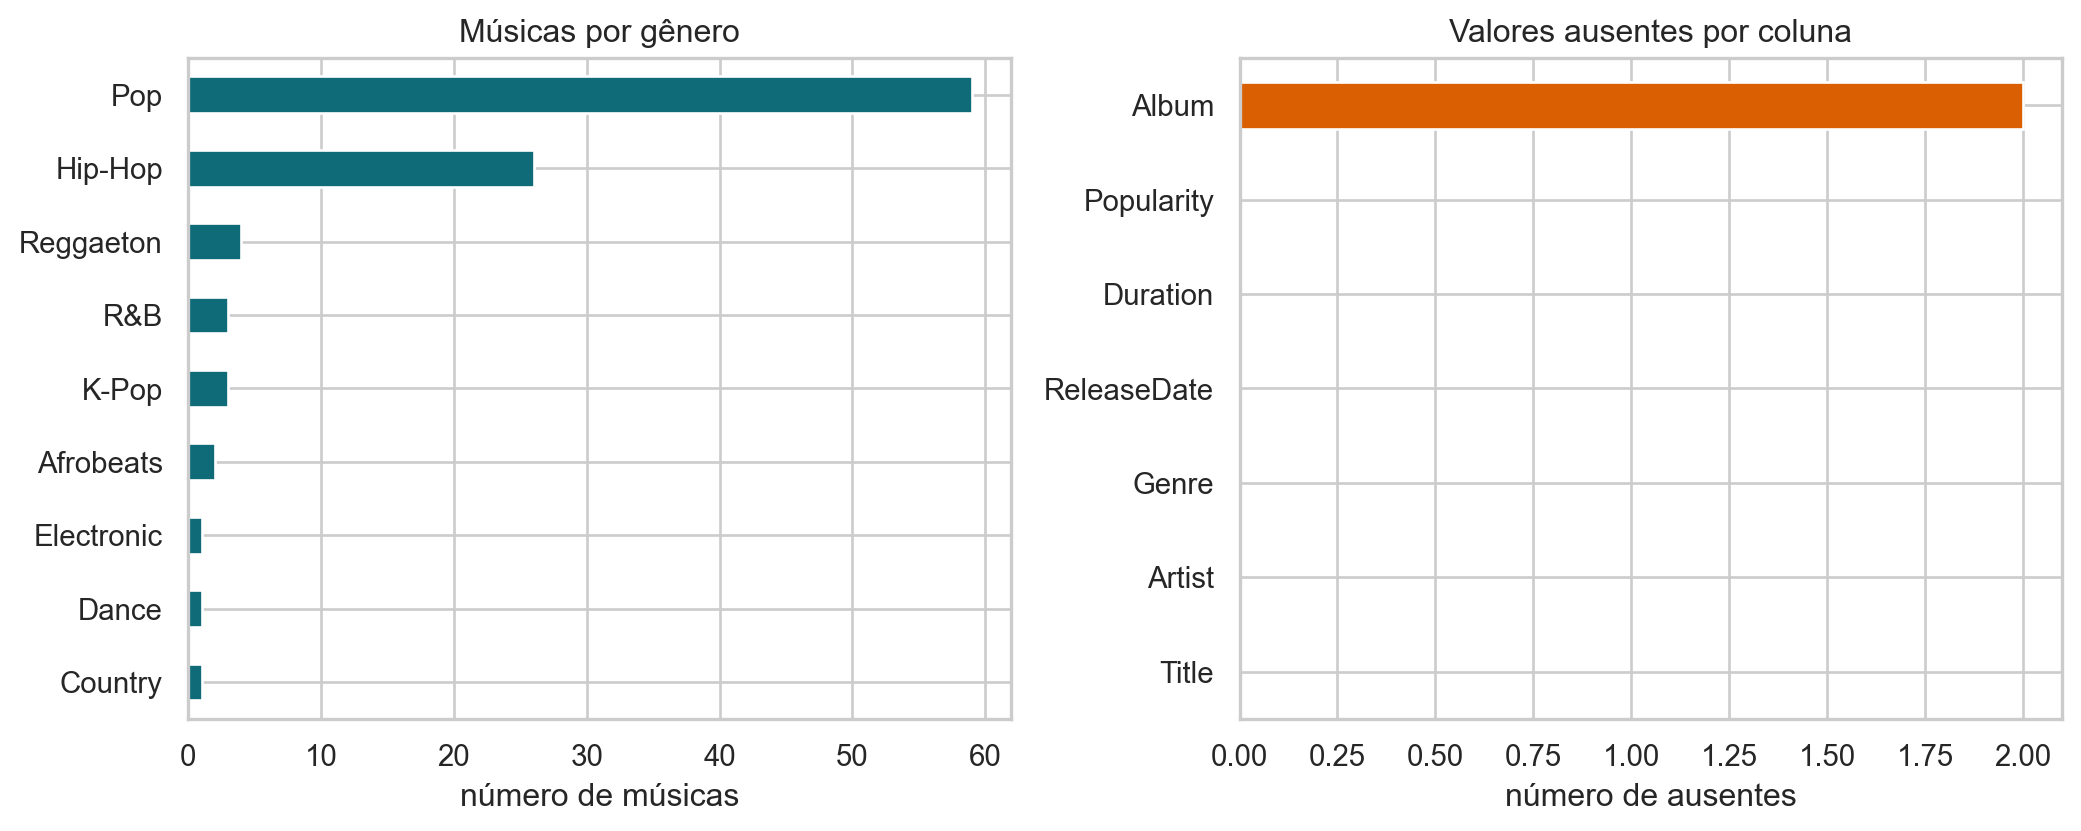

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

songs["Genre"].value_counts().sort_values().plot.barh(ax=axes[0], color="#0f6b78")
axes[0].set_title("Músicas por gênero")
axes[0].set_xlabel("número de músicas")
axes[0].set_ylabel("")

raw.isna().sum().sort_values().plot.barh(ax=axes[1], color="#d95f02")
axes[1].set_title("Valores ausentes por coluna")
axes[1].set_xlabel("número de ausentes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
A base contém 100 músicas, nove gêneros e apenas duas ausências em `Album`; Pop (59) e Hip-Hop (26) dominam a composição. A duração média e a mediana são ambas 3,37 minutos, mas essa coincidência não elimina a necessidade de examinar a forma da distribuição e a representação desigual dos gêneros.
:::

## 5. Pipeline descritivo

A aula segue um roteiro simples:

1. escolher uma coluna numérica;
2. visualizar sua distribuição;
3. calcular resumos;
4. comparar resumos;
5. comunicar o resultado com suas limitações.

O ponto importante é que o resumo final depende das escolhas feitas antes dele. Média, mediana e quartis são úteis, mas não substituem a leitura da distribuição.


## 6. Histograma

O histograma divide a escala numérica em intervalos e conta quantas observações caem em cada intervalo. Ele ajuda a enxergar concentração, assimetria, caudas e valores extremos.


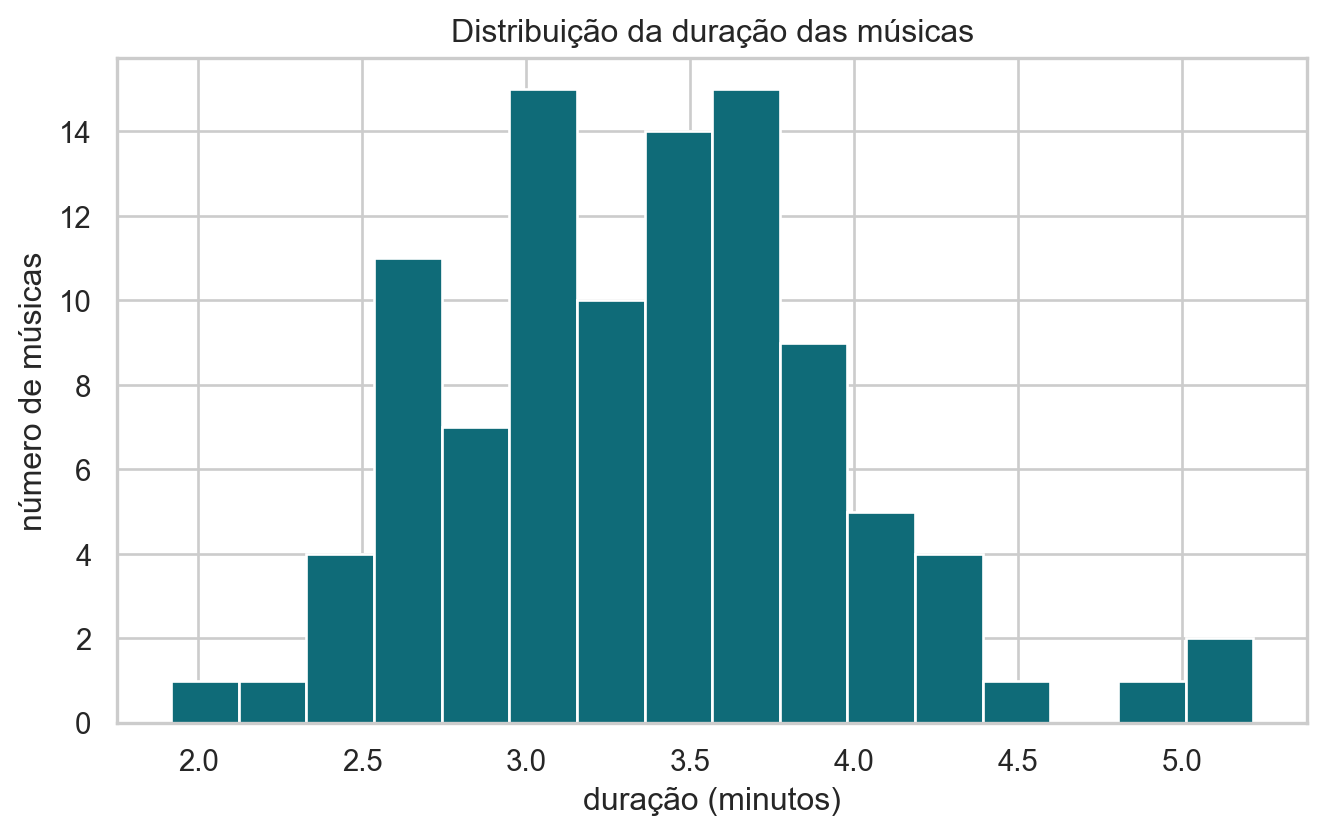

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["duration_min"], bins=16, color="#0f6b78", edgecolor="white")
ax.set_title("Distribuição da duração das músicas")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("número de músicas")
plt.show()


::: {.callout-note title="Interpretação"}
Leia primeiro concentração, assimetria, caudas e valores extremos. Um único resumo de centro não descreve adequadamente uma distribuição longa ou multimodal.
:::

## 7. A escolha dos bins importa

Poucos bins podem esconder detalhes; muitos bins podem sugerir ruído onde há apenas uma amostra pequena. O histograma é uma visualização, portanto envolve escolhas de comunicação.


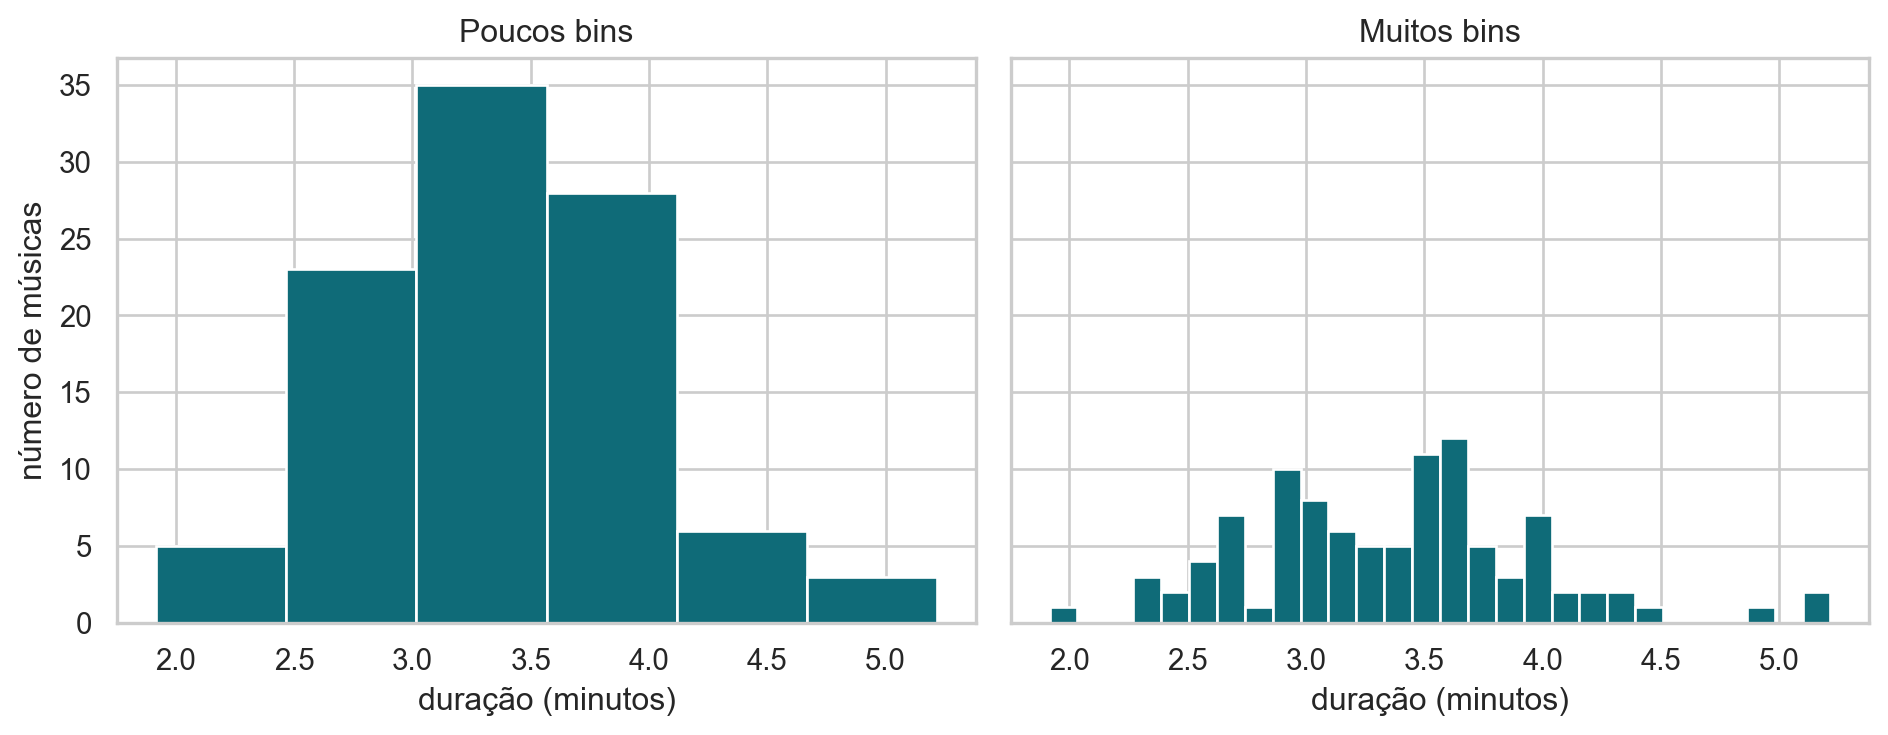

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, bins, title in zip(axes, [6, 28], ["Poucos bins", "Muitos bins"]):
    ax.hist(songs["duration_min"], bins=bins, color="#0f6b78", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("duração (minutos)")

axes[0].set_ylabel("número de músicas")
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
O número de bins controla resolução e ruído. Estruturas que desaparecem quando os limites mudam devem ser verificadas com ECDF, quantis ou outra representação menos dependente dessa escolha.
:::

## 8. CDF empírica

A CDF empírica responde perguntas acumuladas: qual fração das músicas tem duração menor ou igual a certo valor?

Algoritmo:

1. ordenar os valores distintos: `v_1 < v_2 < ... < v_k`;
2. para cada `v_j`, contar `c_j`, o número de observações com `x_i <= v_j`;
3. calcular a frequência acumulada `F_n(v_j) = c_j/n`;
4. desenhar os pares `(v_j, F_n(v_j))` como uma função em degraus, contínua à direita.

Essa contagem acumulada é essencial: `F_n(v_j)` considera todas as observações menores ou iguais a `v_j`, e não apenas a frequência daquele valor. Se houver empates, as observações repetidas entram juntas e recebem a mesma frequência acumulada. Equivalentemente, para qualquer limite `x`, `F_n(x)` é a média dos indicadores `1{x_i <= x}`.


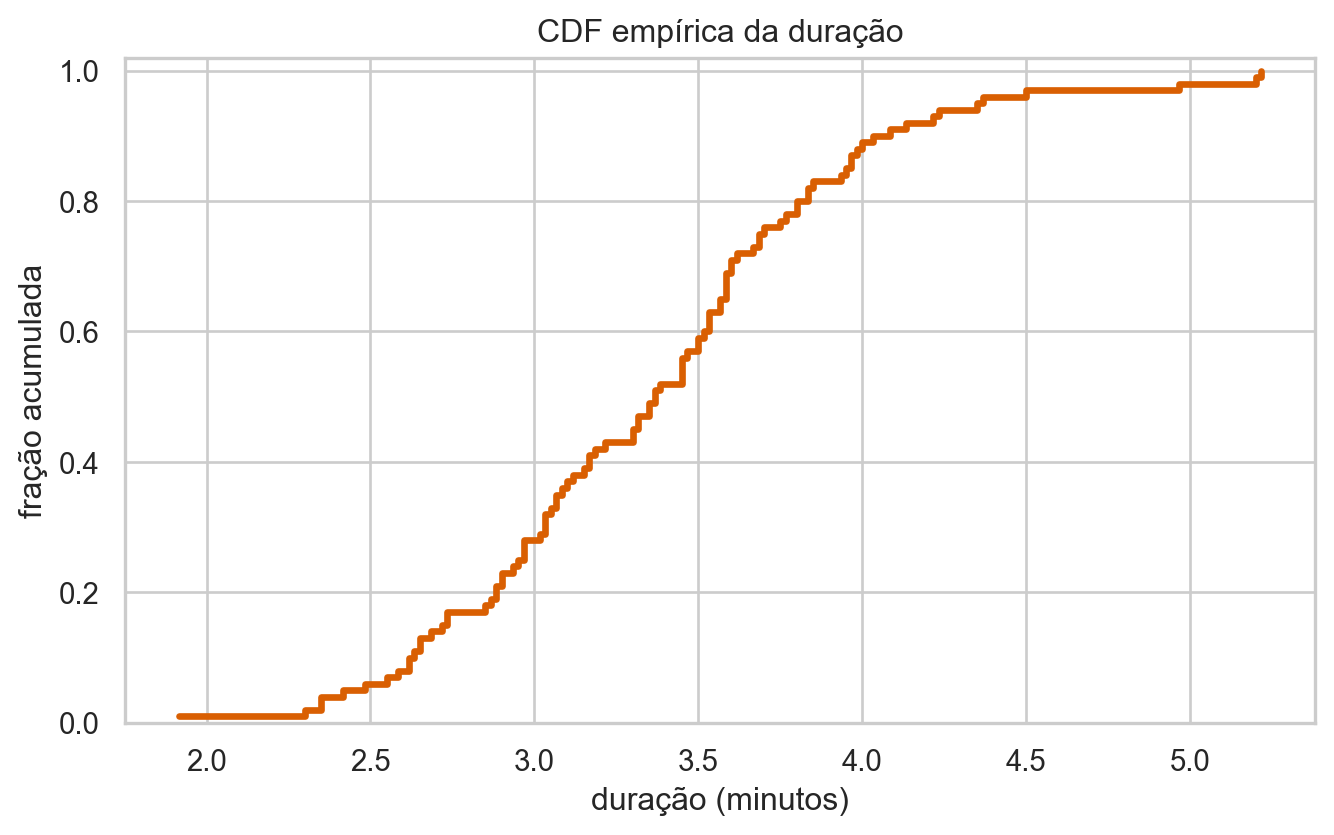

In [12]:
x = np.sort(songs["duration_min"].dropna().to_numpy())
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(x, y, where="post", color="#d95f02", linewidth=2.5)
ax.set_title("CDF empírica da duração")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("fração acumulada")
ax.set_ylim(0, 1.02)
plt.show()


In [13]:
limite = 4
frac_ate_4 = songs["duration_min"].le(limite).mean()
print(f"Fração de músicas com duração até {limite} minutos: {frac_ate_4:.1%}")


Fração de músicas com duração até 4 minutos: 89.0%


::: {.callout-note title="Interpretação"}
Cada altura da CDF é uma proporção acumulada: ela responde diretamente quantas observações são menores ou iguais a um limite. Empates entram juntos nessa contagem.
:::

## 9. Média e mediana

A média usa todos os valores. A mediana usa a posição central dos dados ordenados. Quando a distribuição é assimétrica ou tem valores extremos, as duas podem contar histórias diferentes.


In [14]:
mean_duration = songs["duration_min"].mean()
median_duration = songs["duration_min"].median()

pd.Series({"média": mean_duration, "mediana": median_duration}).round(2)


média      3.37
mediana    3.37
dtype: float64

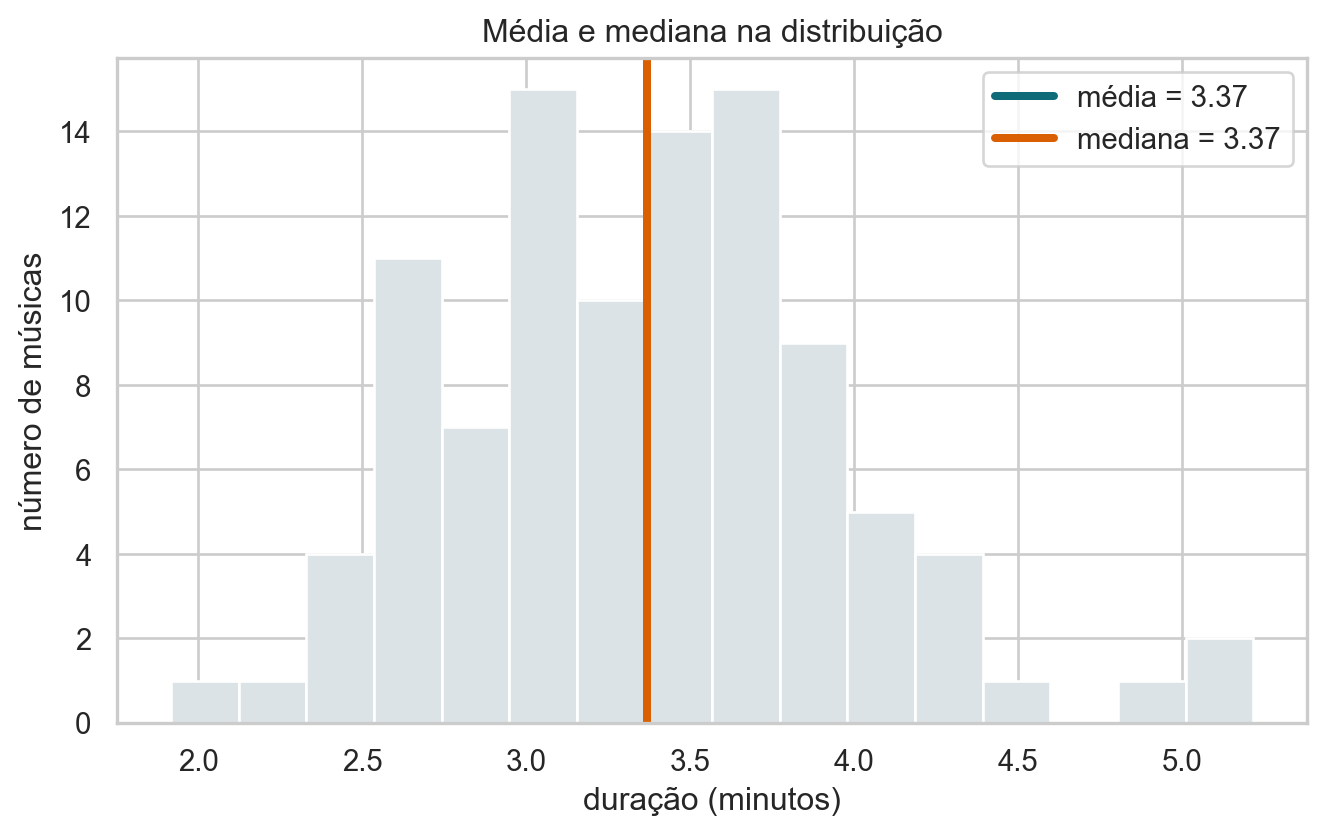

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["duration_min"], bins=16, color="#dbe3e7", edgecolor="white")
ax.axvline(mean_duration, color="#0f6b78", linewidth=3, label=f"média = {mean_duration:.2f}")
ax.axvline(median_duration, color="#d95f02", linewidth=3, label=f"mediana = {median_duration:.2f}")
ax.set_title("Média e mediana na distribuição")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("número de músicas")
ax.legend()
plt.show()


::: {.callout-note title="Interpretação"}
Média e mediana coincidem quando o centro é equilibrado, mas respondem de modo diferente à assimetria. A média usa magnitudes; a mediana depende da ordenação e resiste melhor a valores extremos.
:::

## 10. Mediana versus média em um exemplo didático

No conjunto abaixo, a mediana é o valor central depois de ordenar. A média, por outro lado, é puxada pelos valores extremos `99` e `100`.


In [16]:
valores = np.array([1, 2, 3, 4, 5, 99, 100], dtype=float)
media = valores.mean()
mediana = np.median(valores)

print(f"valores: {valores.astype(int).tolist()}")
print(f"mediana: {mediana:.0f}")
print(f"média: {media:.1f}")


valores: [1, 2, 3, 4, 5, 99, 100]
mediana: 4
média: 30.6


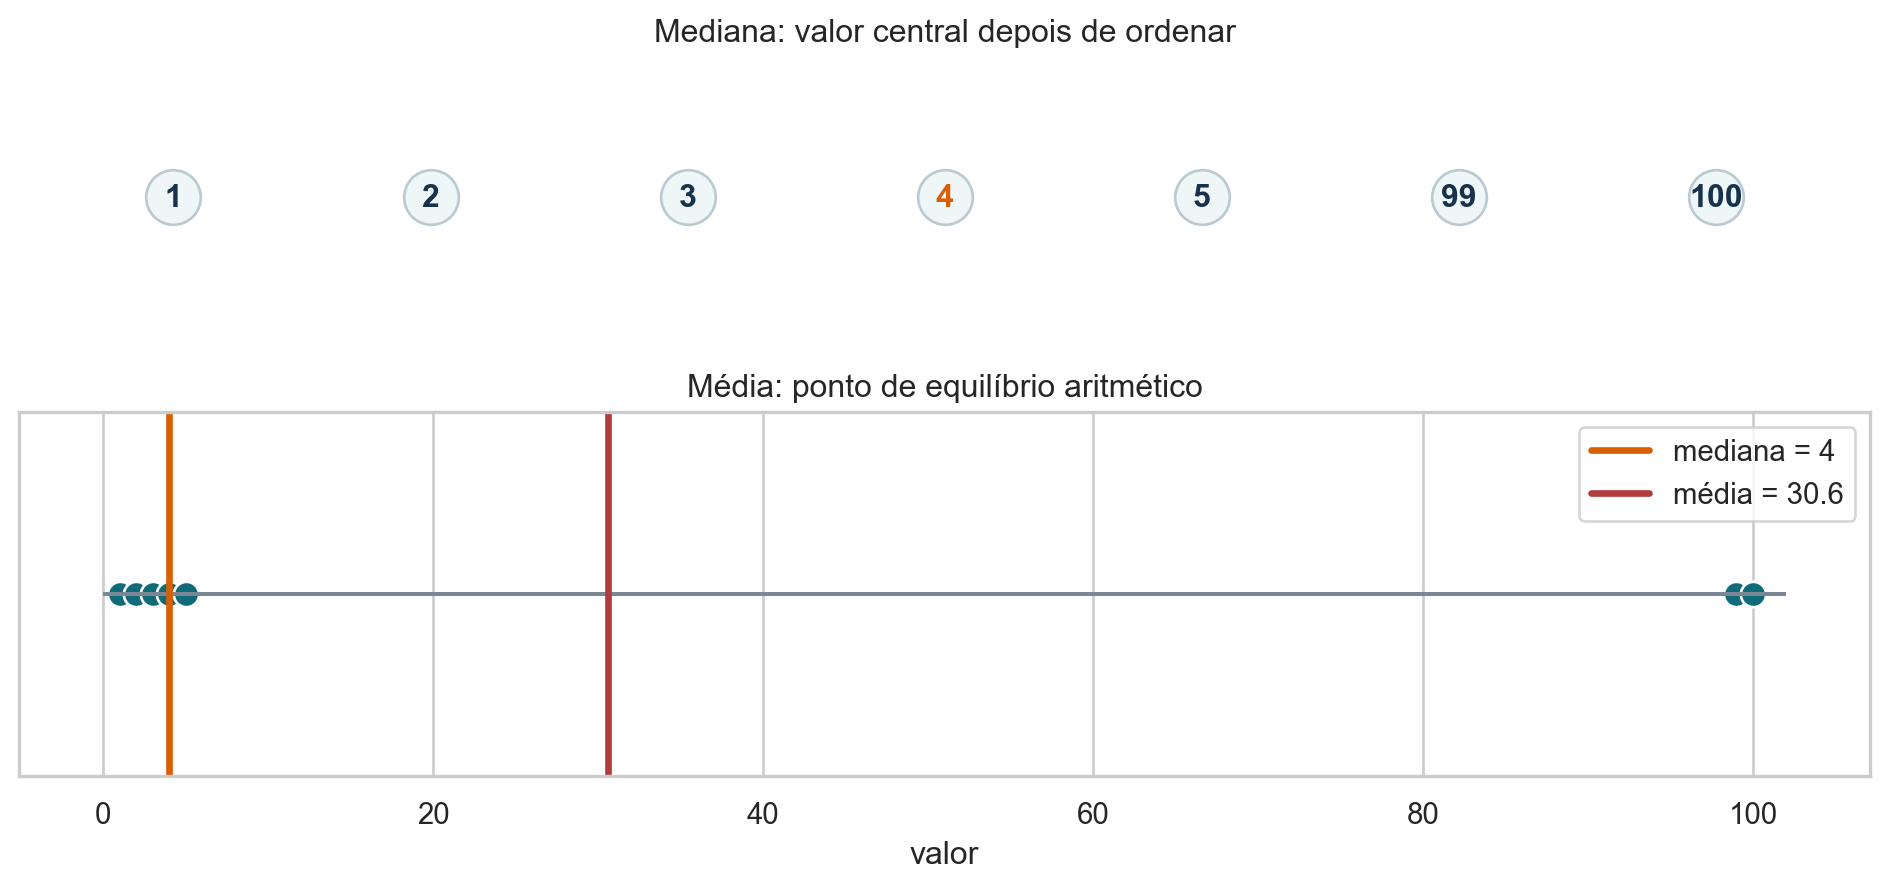

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), height_ratios=[1, 1.3])

ax = axes[0]
ax.set_title("Mediana: valor central depois de ordenar")
ax.scatter(range(len(valores)), np.zeros_like(valores), s=420, color="#eef6f7", edgecolor="#b9cbd1")
for i, valor in enumerate(valores):
    color = "#d95f02" if valor == mediana else "#17324d"
    ax.text(i, 0, f"{valor:.0f}", ha="center", va="center", color=color, fontweight="bold")
ax.set_xlim(-0.6, len(valores) - 0.4)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")

ax = axes[1]
ax.set_title("Média: ponto de equilíbrio aritmético")
ax.hlines(0, 0, 102, color="#7a8794")
ax.scatter(valores, np.zeros_like(valores), s=90, color="#0f6b78", edgecolor="white")
ax.axvline(mediana, color="#d95f02", linewidth=2.5, label=f"mediana = {mediana:.0f}")
ax.axvline(media, color="#b23b3b", linewidth=2.5, label=f"média = {media:.1f}")
ax.set_xlabel("valor")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Nos valores `[1, 2, 3, 4, 5, 99, 100]`, a mediana é 4 porque ocupa a posição central, com três observações de cada lado. A média sobe para 30,6 porque incorpora a magnitude de 99 e 100; o exemplo separa claramente posição central de equilíbrio aritmético.
:::

## 11. Assimetria: quando média e mediana se afastam

Em distribuições simétricas, média e mediana tendem a ficar próximas. Em distribuições assimétricas, a cauda puxa a média.


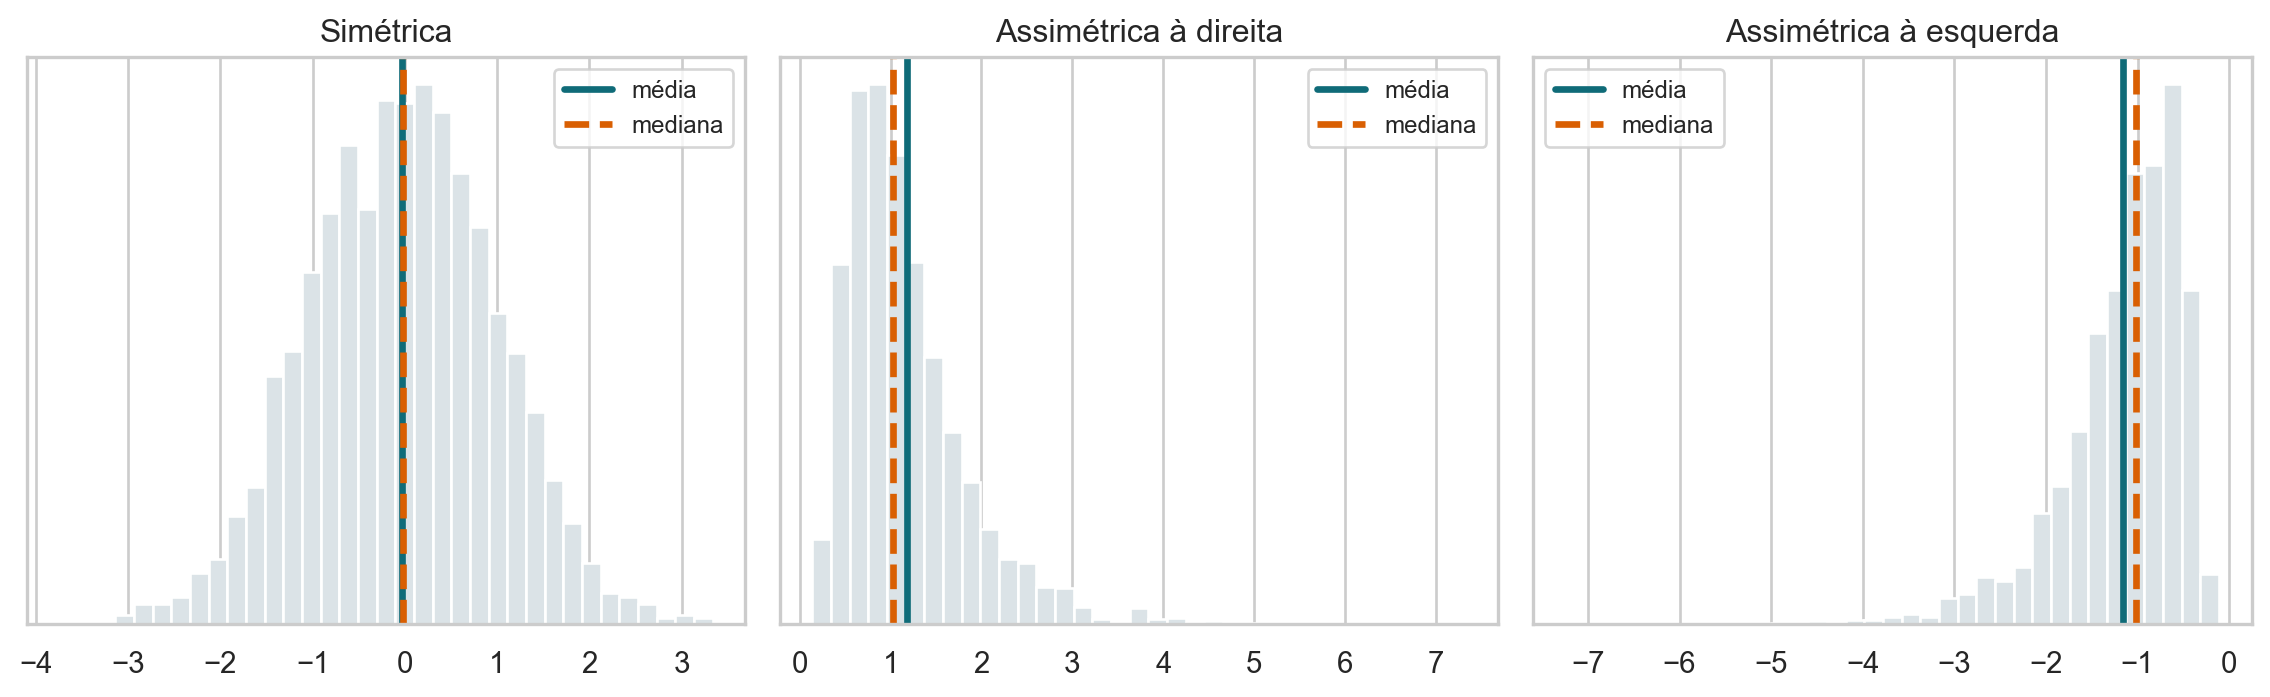

In [18]:
rng = np.random.default_rng(2026)

dados = {
    "Simétrica": rng.normal(0, 1, 3000),
    "Assimétrica à direita": rng.lognormal(0, 0.55, 3000),
    "Assimétrica à esquerda": -rng.lognormal(0, 0.55, 3000),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (titulo, valores_sim) in zip(axes, dados.items()):
    media_sim = valores_sim.mean()
    mediana_sim = np.median(valores_sim)
    ax.hist(valores_sim, bins=35, density=True, color="#dbe3e7", edgecolor="white")
    ax.axvline(media_sim, color="#0f6b78", linewidth=2.5, label="média")
    ax.axvline(mediana_sim, color="#d95f02", linewidth=2.5, linestyle="--", label="mediana")
    ax.set_title(titulo)
    ax.set_yticks([])
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Na distribuição simétrica, média e mediana ficam próximas. A cauda direita desloca a média para valores maiores; a cauda esquerda a desloca para valores menores. A direção da diferença ajuda a diagnosticar assimetria, mas deve ser confirmada pela distribuição completa.
:::

## 12. Experimento com outlier

Vamos adicionar artificialmente uma música de 45 minutos. O objetivo é observar o comportamento dos resumos, não afirmar que esse ponto pertence ao dataset original.


In [19]:
song_long = pd.DataFrame({
    "Title": ["Faixa experimental de 45 minutos"],
    "Artist": ["Exemplo didático"],
    "Genre": ["Experimental"],
    "ReleaseDate": [pd.NaT],
    "Duration": ["45:00"],
    "Album": ["Exemplo"],
    "Popularity": [np.nan],
    "duration_min": [45.0],
})

songs_with_outlier = pd.concat([songs, song_long], ignore_index=True)

comparison = pd.DataFrame({
    "sem outlier": [songs["duration_min"].mean(), songs["duration_min"].median()],
    "com outlier": [songs_with_outlier["duration_min"].mean(), songs_with_outlier["duration_min"].median()],
}, index=["média", "mediana"])
comparison.round(2)


,sem outlier,com outlier
média,3.37,3.78
mediana,3.37,3.37


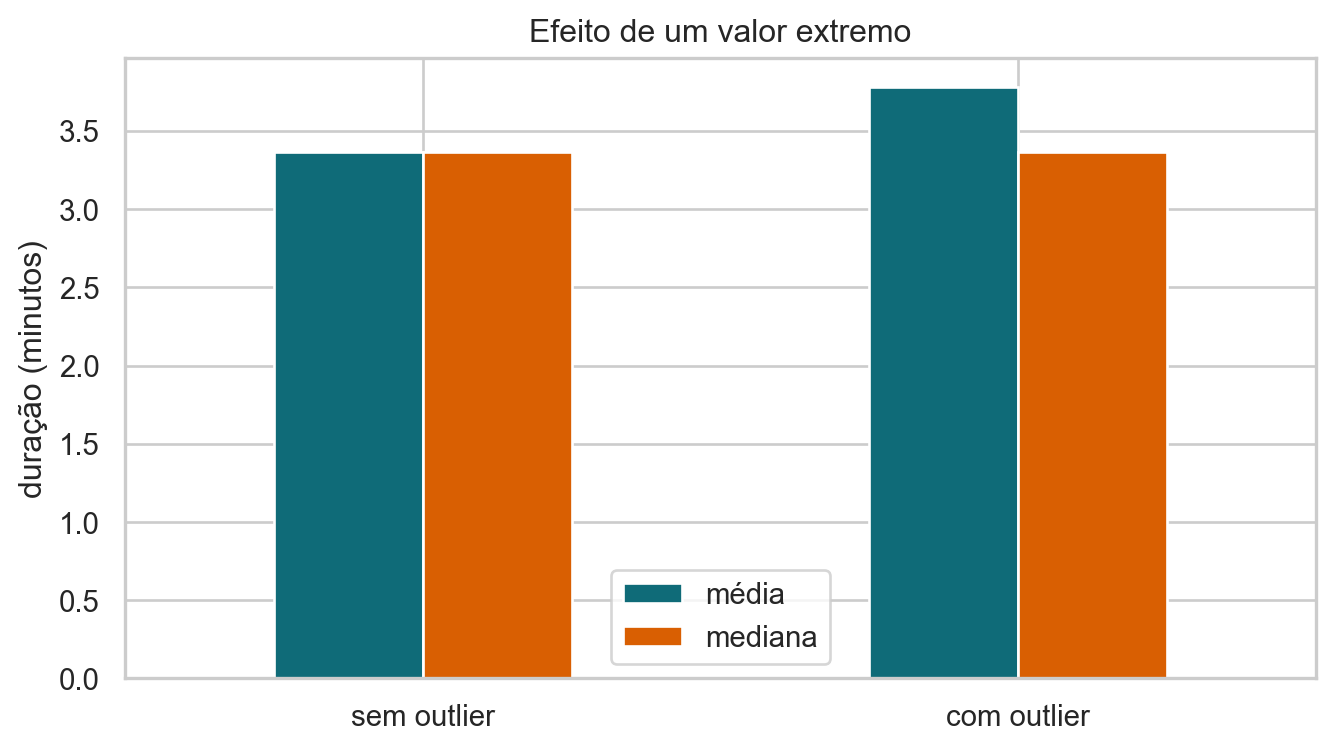

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.2))
comparison.T.plot.bar(ax=ax, color=["#0f6b78", "#d95f02"])
ax.set_title("Efeito de um valor extremo")
ax.set_ylabel("duração (minutos)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()


::: {.callout-note title="Interpretação"}
O valor de 45 minutos altera a média, mas praticamente não muda a mediana. O exercício mostra sensibilidade do estimador; não autoriza remover automaticamente uma observação extrema.
:::

## 13. Quartis

Quartis dividem os dados ordenados em quatro partes. Q1 deixa cerca de 25% dos dados abaixo, a mediana deixa 50% abaixo, e Q3 deixa 75% abaixo.


In [21]:
quartis = songs["duration_min"].quantile([0.25, 0.50, 0.75])
quartis.round(2)


0.25    2.96
0.50    3.37
0.75    3.69
Name: duration_min, dtype: float64

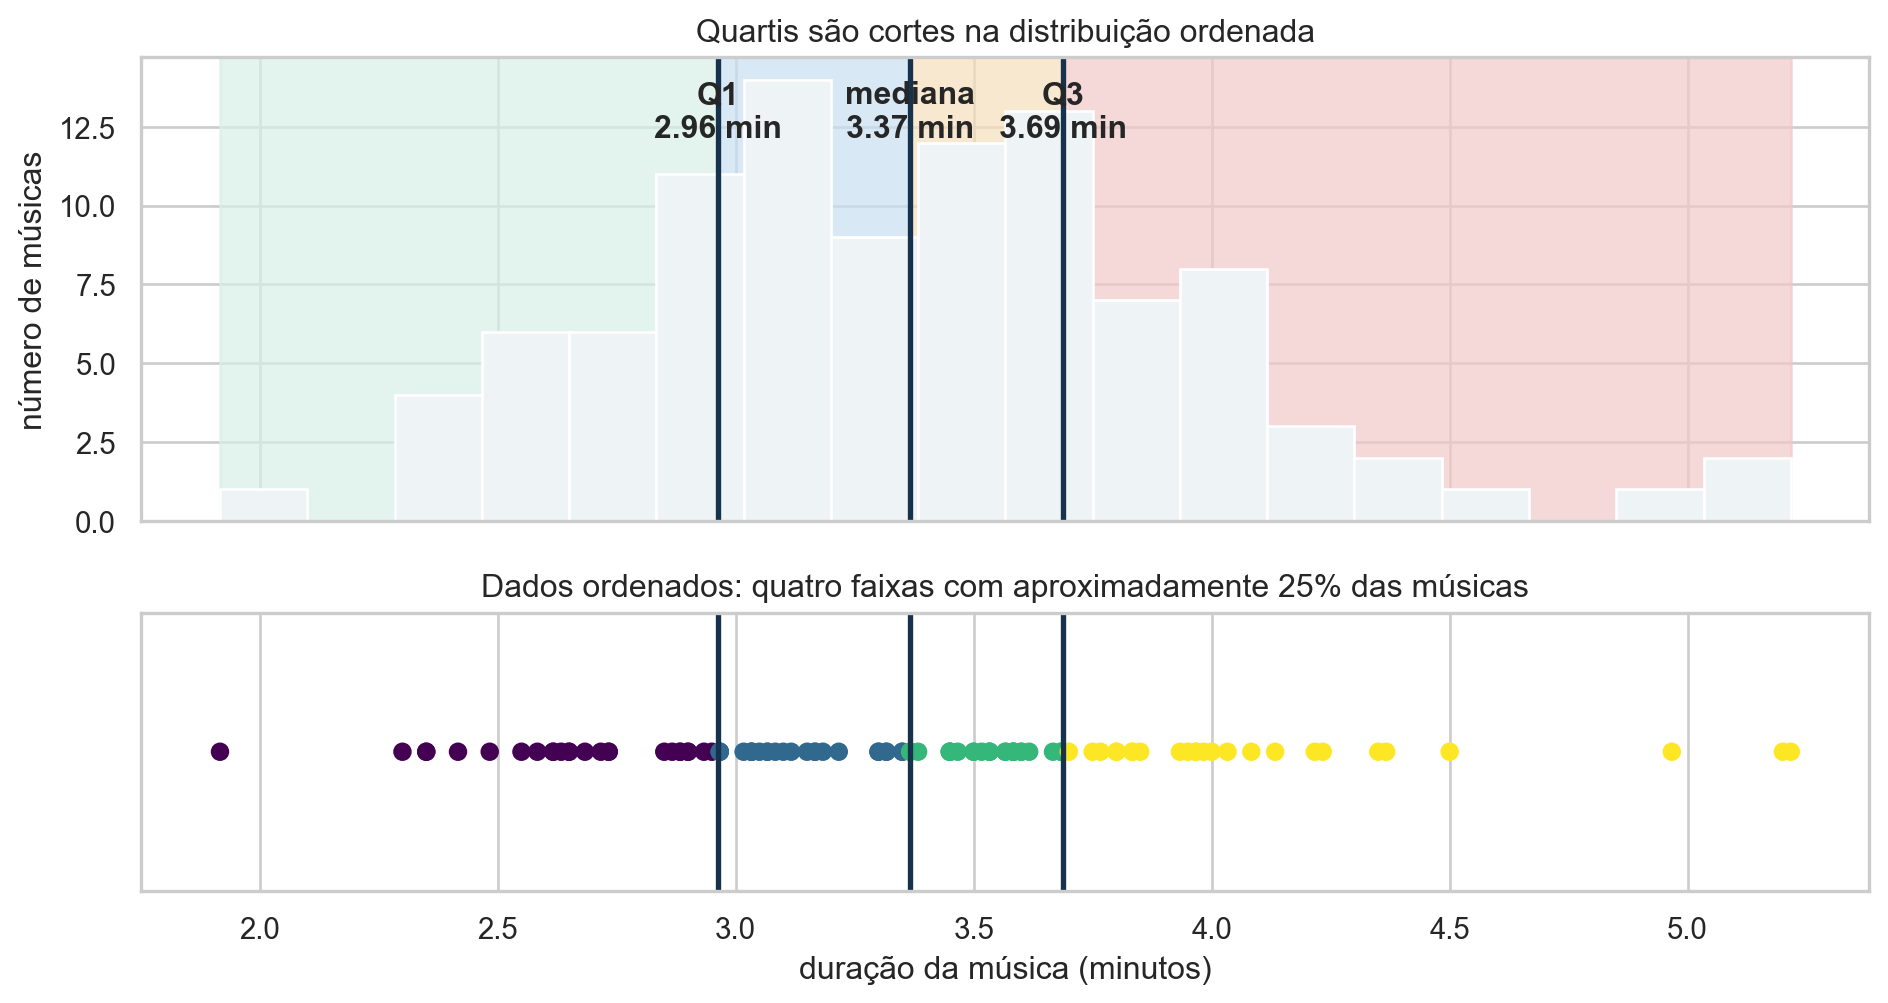

In [22]:
x = songs["duration_min"].dropna().sort_values().to_numpy()
q1, mediana_q, q3 = np.quantile(x, [0.25, 0.50, 0.75])

fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), height_ratios=[2, 1.2], sharex=True)
ax = axes[0]
for lo, hi, color in [(x.min(), q1, "#d8efe7"), (q1, mediana_q, "#c8dff1"), (mediana_q, q3, "#f6dfbd"), (q3, x.max(), "#f2c8c8")]:
    ax.axvspan(lo, hi, color=color, alpha=0.7)
ax.hist(x, bins=18, color="#eef3f6", edgecolor="white")
for value, label in [(q1, "Q1"), (mediana_q, "mediana"), (q3, "Q3")]:
    ax.axvline(value, color="#17324d", linewidth=2)
    ax.text(value, ax.get_ylim()[1] * 0.95, f"{label}\n{value:.2f} min", ha="center", va="top", fontweight="bold")
ax.set_title("Quartis são cortes na distribuição ordenada")
ax.set_ylabel("número de músicas")

ax = axes[1]
quartile_ids = np.searchsorted([q1, mediana_q, q3], x, side="right")
ax.scatter(x, np.zeros_like(x), c=quartile_ids, cmap="viridis", s=35)
for value in [q1, mediana_q, q3]:
    ax.axvline(value, color="#17324d", linewidth=2)
ax.set_title("Dados ordenados: quatro faixas com aproximadamente 25% das músicas")
ax.set_xlabel("duração da música (minutos)")
ax.set_yticks([])
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Q1, mediana e Q3 dividem as observações ordenadas em quatro partes. O intervalo interquartil resume os 50% centrais e é menos sensível às caudas que o intervalo total.
:::

## 14. Boxplot e a regra de 1,5 × IQR

O boxplot usa Q1, mediana e Q3. A caixa vai de Q1 a Q3, e o intervalo interquartil é `IQR = Q3 - Q1`. Uma regra comum marca como potenciais outliers os valores abaixo de `Q1 - 1,5 × IQR` ou acima de `Q3 + 1,5 × IQR`.


In [23]:
q1, mediana_box, q3 = np.quantile(songs["duration_min"], [0.25, 0.50, 0.75])
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

pd.Series({
    "Q1": q1,
    "mediana": mediana_box,
    "Q3": q3,
    "IQR": iqr,
    "limite inferior": limite_inf,
    "limite superior": limite_sup,
}).round(2)


Q1                 2.96
mediana            3.37
Q3                 3.69
IQR                0.72
limite inferior    1.88
limite superior    4.77
dtype: float64

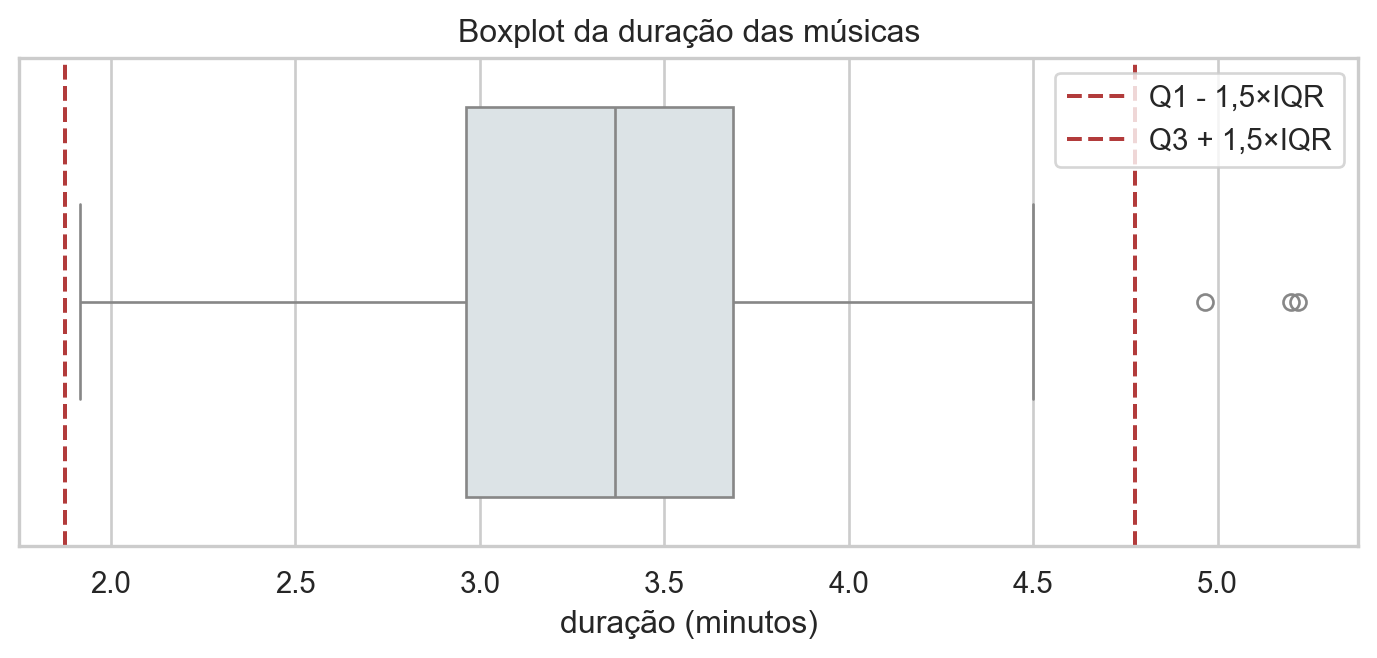

In [24]:
fig, ax = plt.subplots(figsize=(9, 3.3))
sns.boxplot(data=songs, x="duration_min", color="#dbe3e7", ax=ax)
ax.axvline(limite_inf, linestyle="--", color="#b23b3b", label="Q1 - 1,5×IQR")
ax.axvline(limite_sup, linestyle="--", color="#b23b3b", label="Q3 + 1,5×IQR")
ax.set_title("Boxplot da duração das músicas")
ax.set_xlabel("duração (minutos)")
ax.legend(loc="upper right")
plt.show()


::: {.callout-note title="Interpretação"}
O boxplot compacta mediana, quartis e afastamento, mas não mostra sozinho multimodalidade nem tamanho do grupo. Pontos além de 1,5 IQR são candidatos a inspeção, não erros automáticos.
:::

## 15. Boxplot por grupo

Boxplots por grupo ajudam a comparar distribuições, não apenas médias. Aqui, a pergunta passa a ser: os gêneros têm centros e dispersões parecidos?


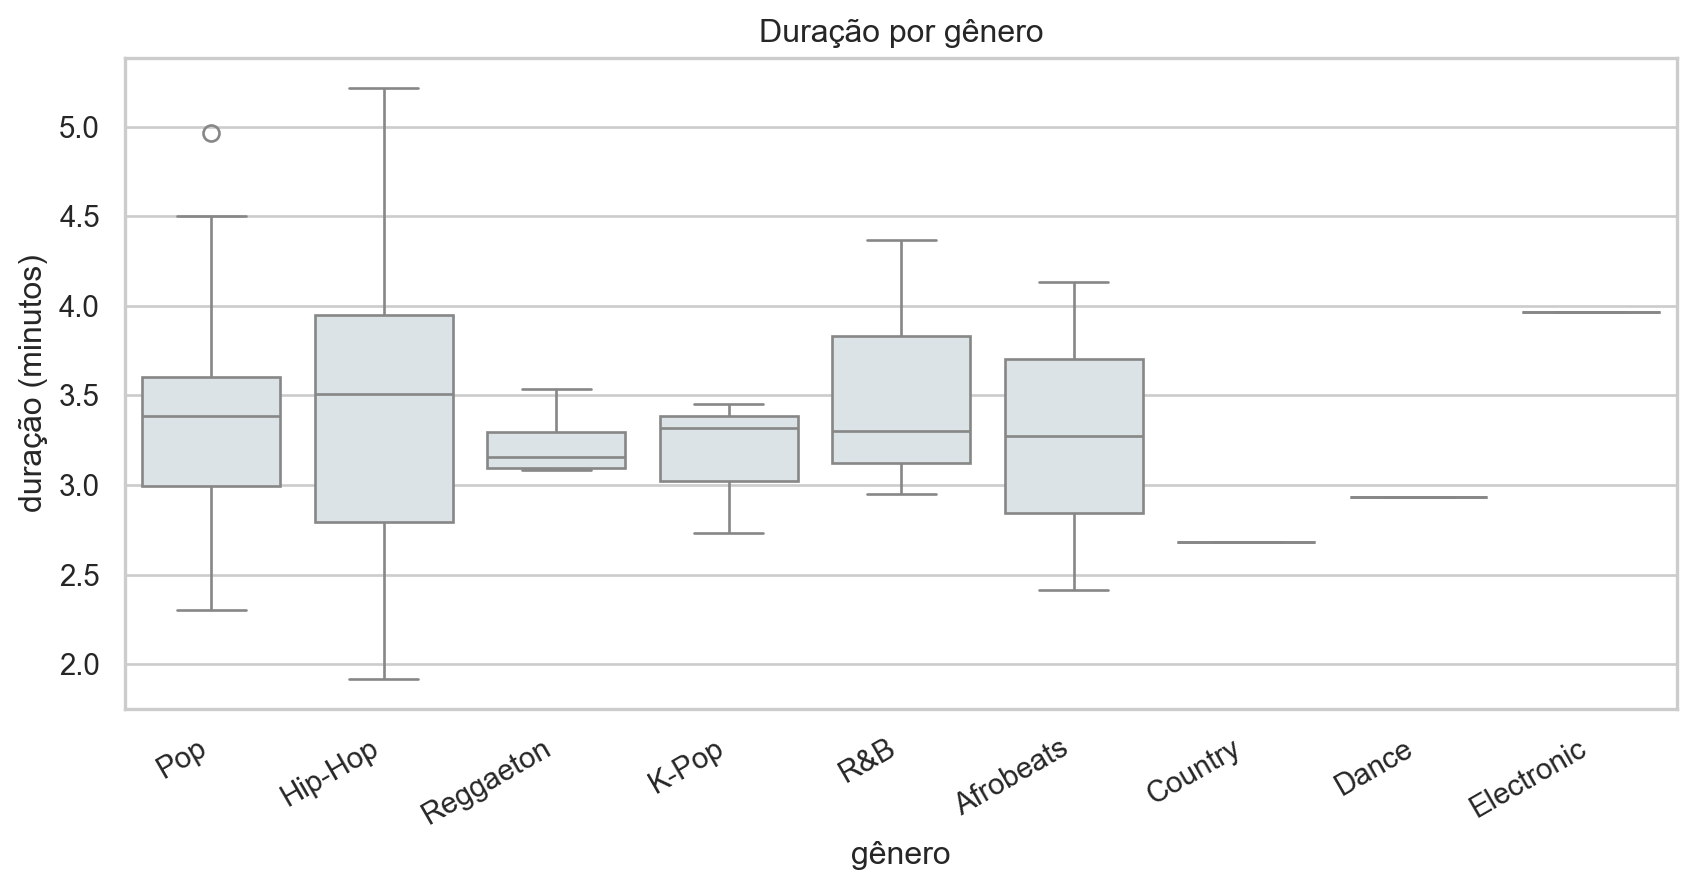

In [25]:
order = songs["Genre"].value_counts().index

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.boxplot(data=songs, x="Genre", y="duration_min", order=order, color="#dbe3e7", ax=ax)
ax.set_title("Duração por gênero")
ax.set_xlabel("gênero")
ax.set_ylabel("duração (minutos)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Compare grupos usando a mesma definição de métrica e mostre também seus tamanhos. Diferenças aparentes podem refletir composição, cobertura ou poucos casos, e não apenas o fator usado no agrupamento.
:::

## 16. Quantis como leituras da CDF

Quantis generalizam quartis. Para um percentual `p`, como 10%, 25%, 50%, 75% ou 90%, o quantil é o valor abaixo do qual está essa fração da amostra.


In [26]:
x = np.sort(songs["duration_min"].dropna().to_numpy())
y = np.arange(1, len(x) + 1) / len(x)
ps = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
qs = np.quantile(x, ps)

pd.DataFrame({"p": ps, "quantil (min)": qs}).round(2)


,p,quantil (min)
0,0.10,2.63
1,0.25,2.96
2,0.50,3.37
3,0.75,3.69
4,0.90,4.04


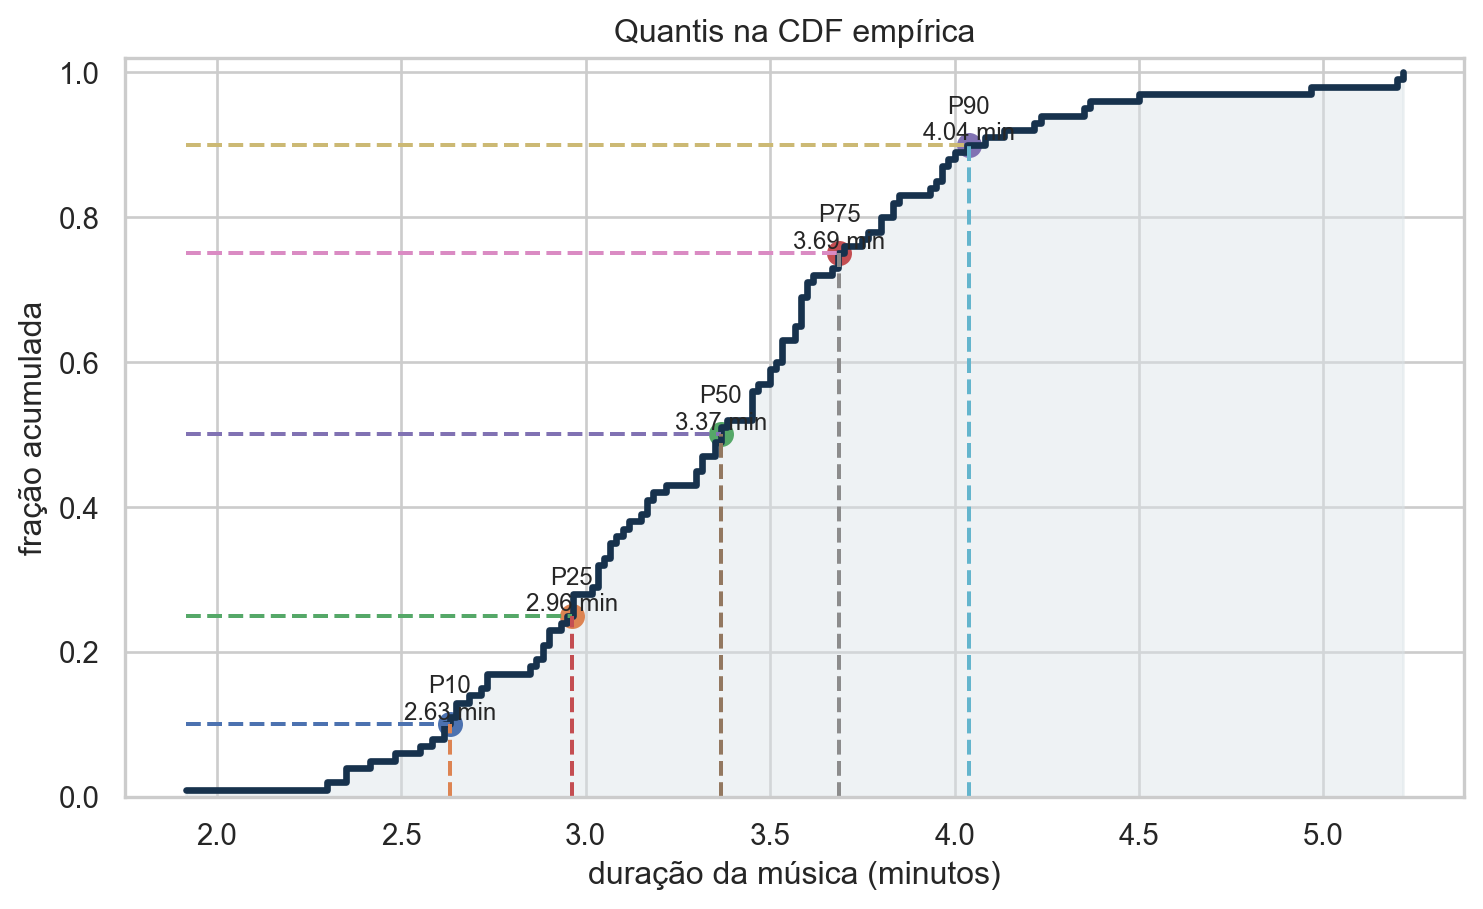

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(x, y, where="post", color="#17324d", linewidth=2.5)
ax.fill_between(x, y, step="post", color="#dbe3e7", alpha=0.45)

for p, q in zip(ps, qs):
    ax.plot([x.min(), q], [p, p], linestyle="--")
    ax.plot([q, q], [0, p], linestyle="--")
    ax.scatter(q, p, s=70)
    ax.text(q, p, f"P{int(p * 100)}\n{q:.2f} min", ha="center", va="bottom", fontsize=9)

ax.set_title("Quantis na CDF empírica")
ax.set_xlabel("duração da música (minutos)")
ax.set_ylabel("fração acumulada")
ax.set_ylim(0, 1.02)
plt.show()


::: {.callout-note title="Interpretação"}
Os quantis transformam proporções acumuladas em valores: 10% das músicas duram até 2,63 minutos, 50% até 3,37 e 90% até 4,04. Assim, o intervalo entre P10 e P90 descreve os 80% centrais sem depender dos valores mais extremos.
:::

## 17. Dispersão, intervalo, variância e desvio padrão

Medidas de centro não dizem tudo. Duas amostras podem ter médias parecidas, mas dispersões muito diferentes.


In [28]:
dispersion = pd.Series({
    "mínimo": songs["duration_min"].min(),
    "máximo": songs["duration_min"].max(),
    "intervalo": songs["duration_min"].max() - songs["duration_min"].min(),
    "variância": songs["duration_min"].var(),
    "desvio padrão": songs["duration_min"].std(),
})
dispersion.round(2)


mínimo           1.92
máximo           5.22
intervalo        3.30
variância        0.37
desvio padrão    0.60
dtype: float64

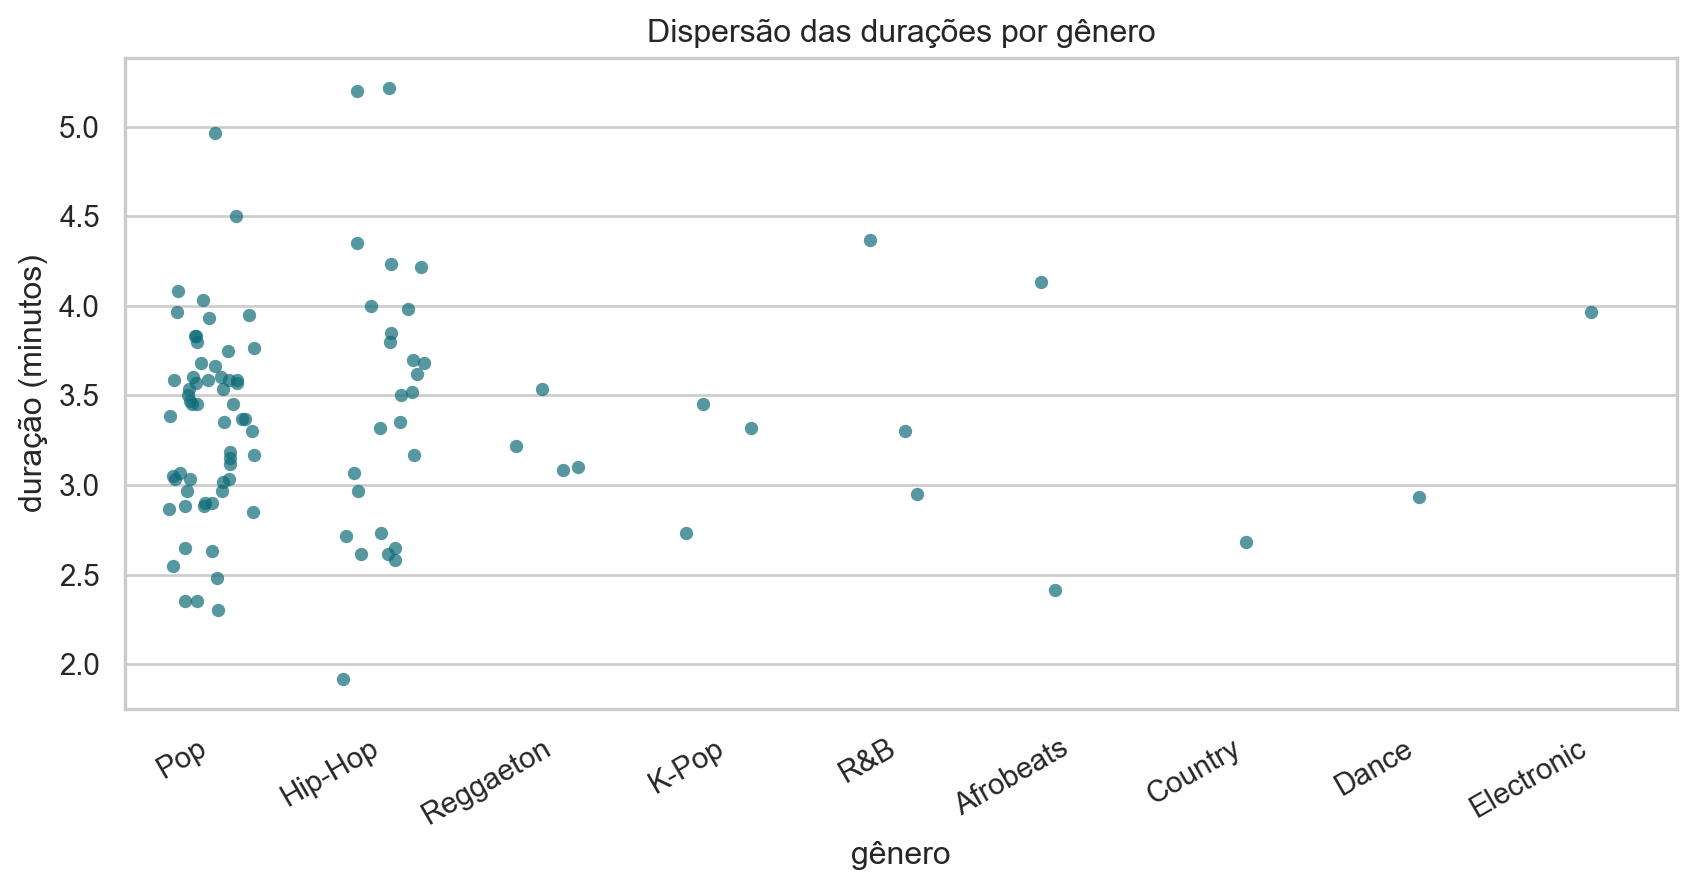

In [29]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.stripplot(data=songs, x="Genre", y="duration_min", order=order, color="#0f6b78", alpha=0.7, jitter=0.25, ax=ax)
ax.set_title("Dispersão das durações por gênero")
ax.set_xlabel("gênero")
ax.set_ylabel("duração (minutos)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Intervalo, IQR, variância e desvio padrão medem aspectos diferentes da dispersão. O intervalo depende dos extremos; o desvio padrão usa todos os desvios e retorna à unidade original.
:::

## 18. Variância: distância em relação à média

A variância cresce quando os valores ficam, em média, mais longe da média. A figura abaixo compara duas amostras com o mesmo centro, mas espalhamentos diferentes.


In [30]:
baixa = np.array([2.9, 3.1, 3.2, 3.3, 3.5, 3.6])
alta = np.array([1.9, 2.4, 2.9, 3.7, 4.2, 4.5])
media_ref = 3.25

pd.DataFrame({
    "baixa variância": [baixa.mean(), baixa.var(ddof=1), baixa.std(ddof=1)],
    "alta variância": [alta.mean(), alta.var(ddof=1), alta.std(ddof=1)],
}, index=["média", "variância", "desvio padrão"]).round(2)


,baixa variância,alta variância
média,3.27,3.27
variância,0.07,1.07
desvio padrão,0.26,1.03


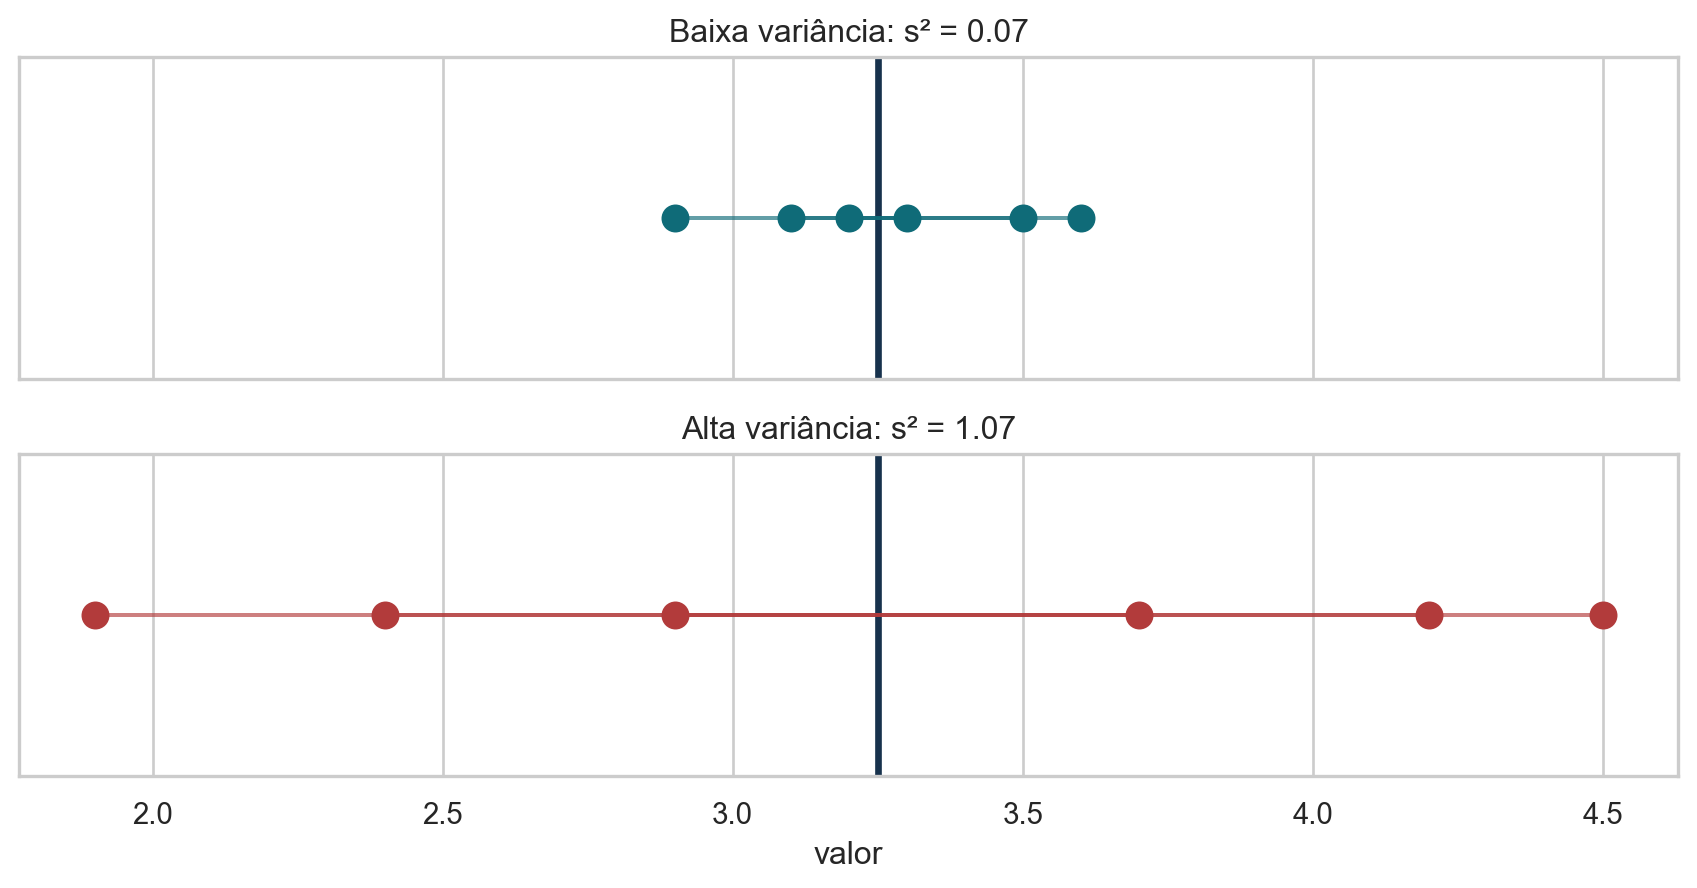

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.8), sharex=True)

for ax, valores_var, titulo, cor in zip(
    axes,
    [baixa, alta],
    ["Baixa variância", "Alta variância"],
    ["#0f6b78", "#b23b3b"],
):
    ax.axvline(media_ref, color="#17324d", linewidth=2.5, label="média")
    ax.scatter(valores_var, np.ones_like(valores_var), color=cor, s=90, zorder=3)
    for value in valores_var:
        ax.plot([media_ref, value], [1, 1], color=cor, alpha=0.65)
    ax.set_title(f"{titulo}: s² = {np.var(valores_var, ddof=1):.2f}")
    ax.set_yticks([])
    ax.set_ylim(0.7, 1.3)

axes[-1].set_xlabel("valor")
plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
Conjuntos com a mesma média podem ter dispersões muito diferentes. Como os desvios são elevados ao quadrado, observações afastadas da média recebem peso crescente na variância.
:::

## 19. Variância populacional e amostral

Quando conhecemos toda a população, dividimos a soma dos quadrados por $N$. Quando uma amostra é usada para estimar a variância populacional, usamos $n-1$:

$$\sigma^2=\frac{1}{N}\sum_i(x_i-\mu)^2,\qquad s^2=\frac{1}{n-1}\sum_i(x_i-\bar{x})^2.$$

A correção tem dois sentidos. Primeiro, os desvios em torno de $\bar{x}$ somam zero, deixando apenas $n-1$ graus de liberdade. Segundo, ajustar a média aos próprios dados reduz sistematicamente a soma dos quadrados: $\mathbb{E}[\sum_i(X_i-\bar X)^2]=(n-1)\sigma^2$. Dividir por $n-1$ remove esse viés para baixo.


In [32]:
duracoes = songs["duration_min"].dropna().to_numpy()
print("Variância descritiva, dividindo por n:  ", np.var(duracoes, ddof=0))
print("Estimativa amostral, dividindo por n-1:", np.var(duracoes, ddof=1))


Variância descritiva, dividindo por n:   0.36210252777777774
Estimativa amostral, dividindo por n-1: 0.3657601290684624


::: {.callout-note title="Interpretação"}
Para estas 100 durações, dividir por n produz 0,3621 min² e dividir por n−1 produz 0,3658 min². A diferença é pequena porque n é grande, mas os objetivos são distintos: o primeiro número descreve o conjunto observado; o segundo corrige o viés ao estimar uma variância populacional a partir da amostra.
:::

## 20. Transformações

Transformações não consertam os dados automaticamente. Elas ajudam a enxergar a distribuição em outra escala, especialmente quando há assimetria forte ou valores muito grandes. Para tornar o efeito visível, adicionaremos artificialmente uma música de **45 minutos**; esse valor é apenas didático e não pertence à base original.

Como o log é monotônico, ele preserva a ordem dos valores. Na escala original, 45 minutos comprime visualmente as músicas usuais entre 2 e 5 minutos. Na escala logarítmica, distâncias representam razões e a cauda ocupa menos espaço.


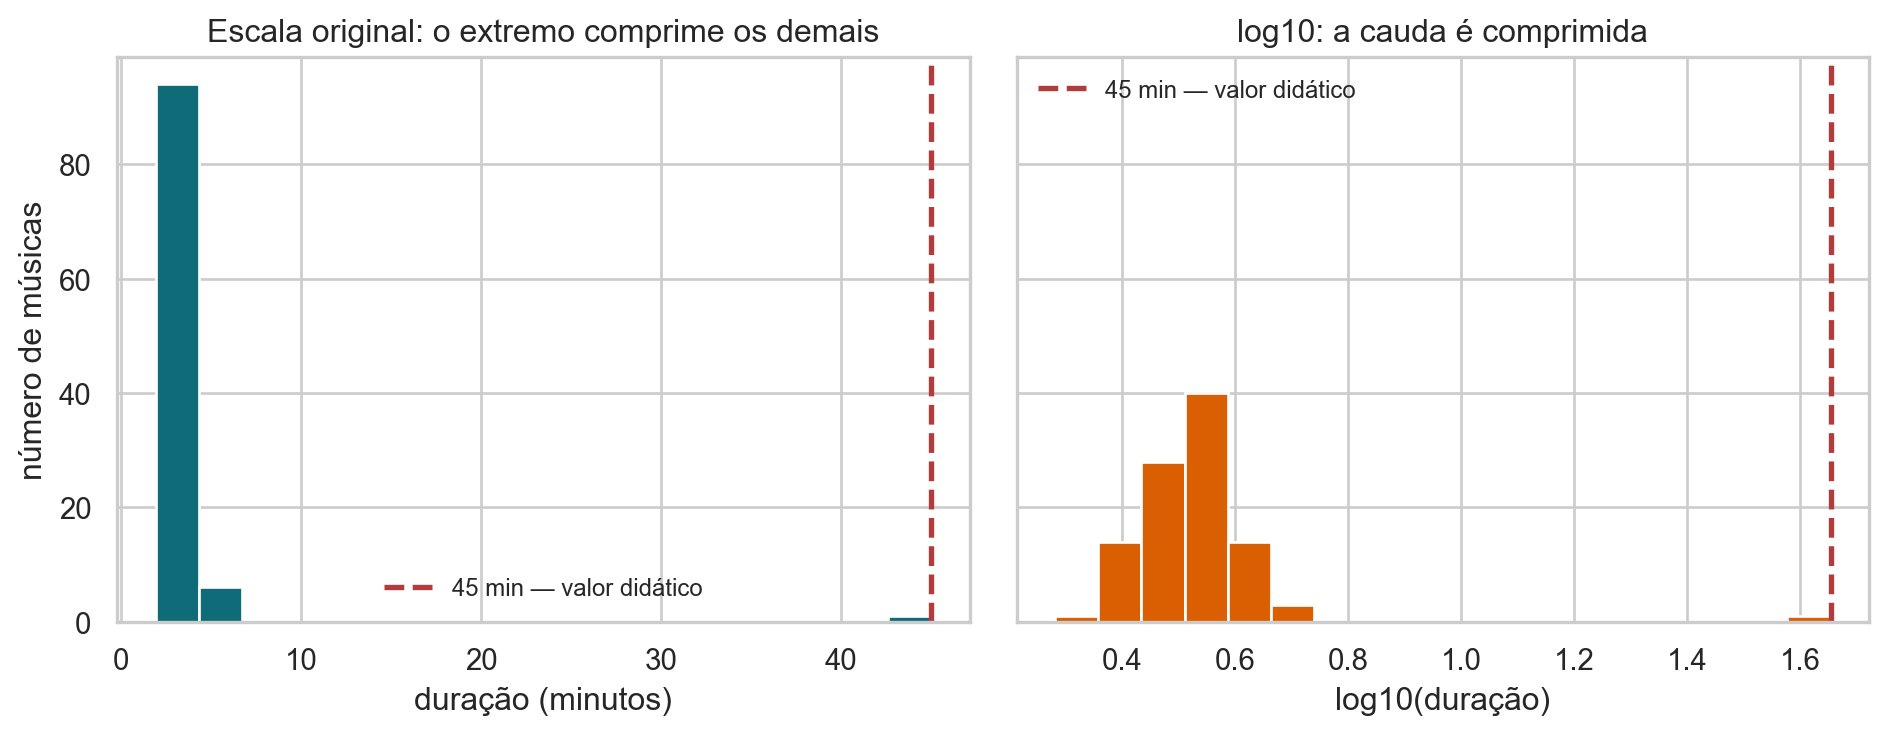

In [33]:
duracao_com_extremo = pd.concat(
    [songs["duration_min"], pd.Series([45.0])],
    ignore_index=True
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(duracao_com_extremo, bins=18, color="#0f6b78", edgecolor="white")
axes[0].axvline(45, color="#b23b3b", linestyle="--", linewidth=2, label="45 min — valor didático")
axes[0].set_title("Escala original: o extremo comprime os demais")
axes[0].set_xlabel("duração (minutos)")
axes[0].set_ylabel("número de músicas")

axes[1].hist(np.log10(duracao_com_extremo), bins=18, color="#d95f02", edgecolor="white")
axes[1].axvline(np.log10(45), color="#b23b3b", linestyle="--", linewidth=2, label="45 min — valor didático")
axes[1].set_title("log10: a cauda é comprimida")
axes[1].set_xlabel("log10(duração)")

for ax in axes:
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


::: {.callout-note title="Interpretação"}
O log preserva a ordem, mas transforma razões em distâncias. No exemplo didático, a observação de 45 minutos comprime a escala original; após o log, a região entre 2 e 5 minutos volta a ficar legível.
:::

## 21. Popularidade: repetindo o roteiro

Depois de entender duração, podemos aplicar o mesmo roteiro a outra variável numérica: visualizar a distribuição, calcular resumos e comparar média e mediana.


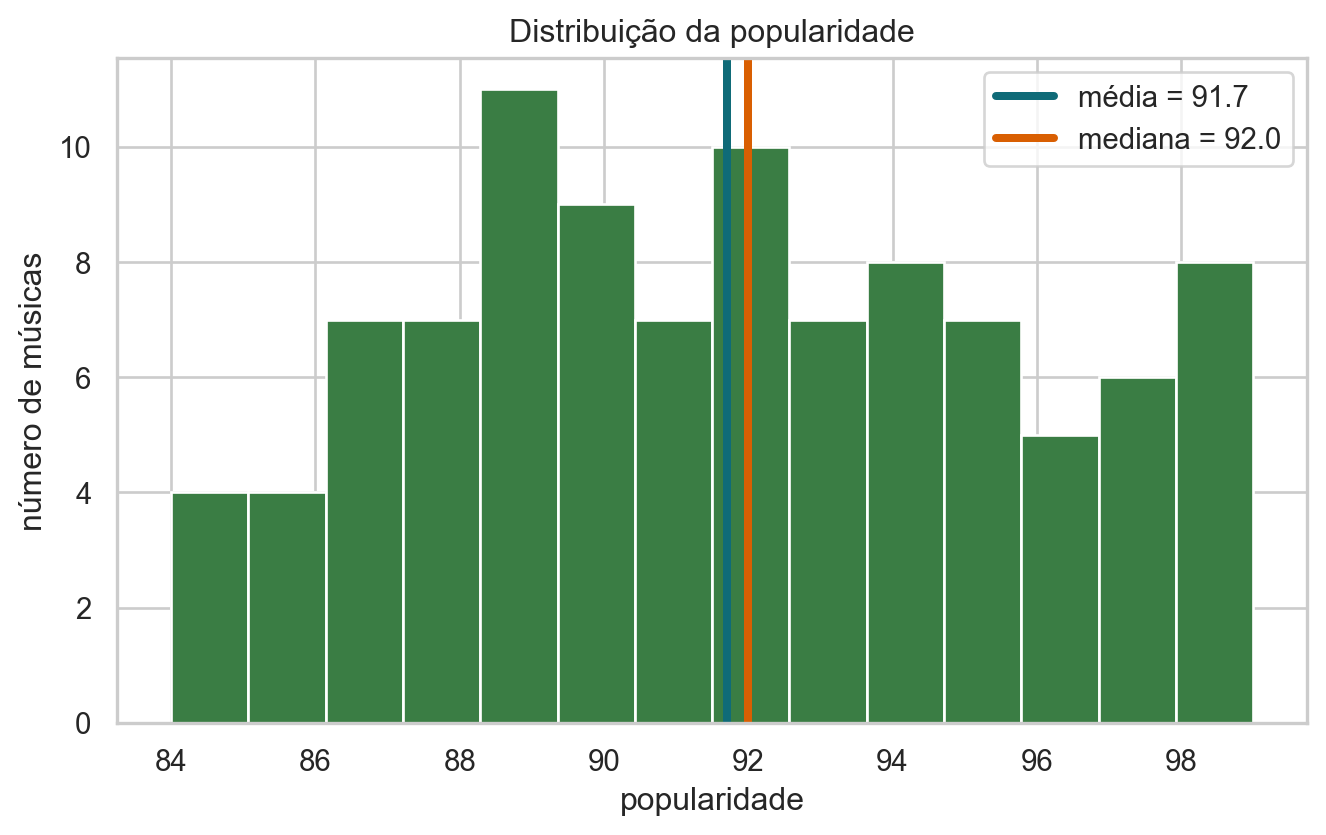

In [34]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["Popularity"], bins=14, color="#3a7d44", edgecolor="white")
ax.axvline(songs["Popularity"].mean(), color="#0f6b78", linewidth=3, label=f"média = {songs['Popularity'].mean():.1f}")
ax.axvline(songs["Popularity"].median(), color="#d95f02", linewidth=3, label=f"mediana = {songs['Popularity'].median():.1f}")
ax.set_title("Distribuição da popularidade")
ax.set_xlabel("popularidade")
ax.set_ylabel("número de músicas")
ax.legend()
plt.show()


::: {.callout-note title="Interpretação"}
Repita o roteiro sem presumir que a nova variável tem a mesma forma da duração: visualize, examine limites e ausências, e só então escolha os resumos de centro e dispersão.
:::

## 22. Outras médias: geométrica e harmônica

A média aritmética não é a única média possível.

A **média geométrica** é útil para grandezas multiplicativas ou valores normalizados positivos:

$$
G = \sqrt[n]{x_1 x_2 \cdots x_n} = \left(\prod_{i=1}^{n} x_i\right)^{1/n}
$$

A **média harmônica** é útil para taxas quando as quantidades-base são comparáveis:

$$
H = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}
$$


In [35]:
avaliacoes_normalizadas = np.array([0.60, 0.70])
media_geometrica = np.prod(avaliacoes_normalizadas) ** (1 / len(avaliacoes_normalizadas))

velocidades = np.array([20, 30])
media_harmonica = len(velocidades) / np.sum(1 / velocidades)

pd.Series({
    "média geométrica de 60% e 70%": media_geometrica,
    "média harmônica de 20 e 30 km/h": media_harmonica,
}).round(3)


média geométrica de 60% e 70%       0.65
média harmônica de 20 e 30 km/h    24.00
dtype: float64

::: {.callout-note title="Interpretação"}
A média geométrica é adequada a fatores multiplicativos; a harmônica, a taxas com numerador fixo. Elas não são substitutas automáticas da média aritmética: a pergunta e a unidade determinam a escolha.
:::

## 23. Para estudar

Experimente modificar as células acima:

- mude o número de bins do histograma;
- escolha outro limite na CDF empírica;
- compare média e mediana por gênero;
- troque os percentis usados na figura de quantis;
- adicione outros valores extremos e observe média, mediana e boxplot.

A pergunta que deve acompanhar cada alteração é: **a conclusão mudou ou apenas a forma de comunicar mudou?**


## 24. Autoavaliação comentada

As perguntas interativas dos slides reaparecem aqui como revisão. Tente responder antes de abrir a explicação.

### 1. Uma faixa de 45 minutos entra na base. Qual resumo muda mais?

**Resposta:** a média. Ela usa a magnitude de todos os valores e, portanto, é deslocada por uma observação extrema. A mediana depende principalmente da ordem e da posição central; com uma única nova faixa, tende a mudar pouco. Isso não torna a média errada: indica apenas que ela responde a uma pergunta mais sensível às caudas da distribuição.

### 2. Se $F_n(4)=0{,}89$, o que isso significa?

**Resposta:** 89% das músicas observadas têm duração menor ou igual a 4 minutos. A CDF é acumulada: ela não informa a proporção exatamente igual a 4, nem permite obter a média multiplicando 0,89 por 4. Os 11% restantes estão acima desse ponto.

### 3. Por que a variância amostral usa $n-1$?

Duas ideias se complementam:

1. depois de estimar $\bar X$, os desvios somam zero e apenas $n-1$ deles são livres;
2. a soma $\sum_i(X_i-\bar X)^2$ tem esperança $(n-1)\sigma^2$, de modo que dividir por $n$ manteria um viés para baixo.

A correção de Bessel remove esse viés **em média**. Ela não garante que a variância calculada em toda amostra seja exatamente igual à variância populacional, e nenhuma observação é descartada.

::: {.callout-tip title="Como usar estas questões"}
Se uma resposta pareceu óbvia apenas depois de ler a explicação, volte à figura correspondente e tente formular a justificativa com suas próprias palavras. O objetivo é reconhecer a ideia em um novo contexto, não memorizar a alternativa correta.
:::


# Guia teórico ampliado da Aula 07

## Centro, posição e dispersão

A média $\bar x=n^{-1}\sum_i x_i$ usa todos os valores e minimiza a soma dos erros quadráticos. A mediana é um quantil de ordem 0,5, depende da posição ordenada e é mais robusta a extremos. Quartis e quantis descrevem posições na distribuição; o intervalo interquartil $IQR=Q_3-Q_1$ resume os 50% centrais.

Variância mede distância quadrática ao centro. A variância populacional usa a média conhecida $\mu$ e divisor $N$. Para estimar a variância populacional a partir de uma amostra, usamos

$$s^2=\frac{1}{n-1}\sum_{i=1}^n(X_i-\bar X)^2.$$

## Caminho 1: graus de liberdade

Os desvios em torno da média amostral satisfazem

$$\sum_{i=1}^n(X_i-\bar X)=0.$$

Depois de conhecidos $n-1$ desvios, o último está determinado. Há apenas $n-1$ componentes livres de variação.

## Caminho 2: decomposição dos desvios

Escrevemos

$$X_i-\bar X=(X_i-\mu)-(\bar X-\mu).$$

Elevando ao quadrado e somando:

$$\begin{aligned}
\sum_{i=1}^n(X_i-\bar X)^2
={}&\sum_{i=1}^n(X_i-\mu)^2
-2(\bar X-\mu)\sum_{i=1}^n(X_i-\mu)\\
&+\sum_{i=1}^n(\bar X-\mu)^2.
\end{aligned}$$

Usamos

$$\sum_{i=1}^n(X_i-\mu)=n(\bar X-\mu)$$

e

$$\sum_{i=1}^n(\bar X-\mu)^2=n(\bar X-\mu)^2.$$

Logo,

$$\boxed{\sum_{i=1}^n(X_i-\bar X)^2
=\sum_{i=1}^n(X_i-\mu)^2-n(\bar X-\mu)^2}.$$

A média amostral é o centro que melhor se ajusta aos próprios dados; por isso a dispersão em torno de $\bar X$ é menor.

## A esperança revela $n-1$

Para observações i.i.d. com variância $\sigma^2$,

$$\mathbb E\left[\sum_{i=1}^n(X_i-\mu)^2\right]=n\sigma^2.$$

Como $\mathbb E[\bar X]=\mu$,

$$\mathbb E[(\bar X-\mu)^2]=\operatorname{Var}(\bar X)=\frac{\sigma^2}{n},$$

e portanto

$$\mathbb E[n(\bar X-\mu)^2]=\sigma^2.$$

Combinando os termos:

$$\begin{aligned}
\mathbb E\left[\sum_{i=1}^n(X_i-\bar X)^2\right]
&=\mathbb E\left[\sum_{i=1}^n(X_i-\mu)^2\right]
-\mathbb E[n(\bar X-\mu)^2]\\
&=n\sigma^2-\sigma^2\\
&=(n-1)\sigma^2.
\end{aligned}$$

Dividir por $n$ produziria esperança $\frac{n-1}{n}\sigma^2$, um viés para baixo. Dividir por $n-1$ produz $\mathbb E[s^2]=\sigma^2$. Isso torna a variância amostral não enviesada; não significa que uma amostra específica recupere exatamente $\sigma^2$. O desvio-padrão $s=\sqrt{s^2}$ ainda possui pequeno viés por causa da raiz quadrada.
